# 05 — Полный pipeline для всех пяти примеров и трёх словарей

Этот ноутбук запускает data-driven идентификацию и анализ робастной устойчивости для всех пяти эталонных систем, используя три словаря `Θ(x)`:
- линейный;
- квадратичный без константы;
- квадратичный с константой.

В ноутбуке показываются только сводные графики и таблицы. Подробные фазовые траектории и графики распределения residuals сохраняются на диск в отдельную папку результатов этого ноутбука.


In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import ensure_dir, save_dataframe, save_json, set_seed
from src.systems import get_example_system
from src.simulation import simulate_batch, uncertain_dynamics
from src.plots import plot_residual_error_distributions, save_figure, set_plot_style
from src.basis import get_basis
from src.identification import fit_identified_model, predict_vector_field
from src.uncertainty import compute_residuals, residual_norms, estimate_epsilon, bounded_disturbance
from src.lyapunov import numerical_jacobian, solve_lyapunov
from src.control import candidate_gains

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass


## Инициализация


In [24]:
set_seed(42)
set_plot_style()

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
NOTEBOOK_RESULTS = ROOT / 'results' / 'main_pipeline'
FIGURES_DIR = ensure_dir(NOTEBOOK_RESULTS / 'figures')
METRICS_DIR = ensure_dir(NOTEBOOK_RESULTS / 'metrics')
TABLES_DIR = ensure_dir(NOTEBOOK_RESULTS / 'tables')
DATASETS_DIR = ensure_dir(NOTEBOOK_RESULTS / 'datasets')

examples = [
    'linear_damped',
    'quadratic_oscillator',
    'van_der_pol',
    'cross_coupled',
    'saturated',
]

basis_configs = {
    'linear': {
        'basis_fn': get_basis('linear'),
        'theta_terms': ['x1', 'x2'],
        'title': 'Linear',
    },
    'quadratic': {
        'basis_fn': get_basis('quadratic'),
        'theta_terms': ['x1', 'x2', 'x1^2', 'x2^2', 'x1*x2'],
        'title': 'Quadratic',
    },
    'quadratic_with_constant': {
        'basis_fn': get_basis('quadratic_with_constant'),
        'theta_terms': ['1', 'x1', 'x2', 'x1^2', 'x2^2', 'x1*x2'],
        'title': 'Quadratic + constant',
    },
}

print(f'Папка результатов ноутбука: {NOTEBOOK_RESULTS}')
print(f'Примеры: {examples}')
print(f'Словари: {list(basis_configs)}')


Папка результатов ноутбука: /Users/maksimkuznecov/Desktop/graduate_work/robust-dd-control/results/main_pipeline
Примеры: ['linear_damped', 'quadratic_oscillator', 'van_der_pol', 'cross_coupled', 'saturated']
Словари: ['linear', 'quadratic', 'quadratic_with_constant']


## Параметры моделирования и служебные функции


In [25]:
t_eval = np.linspace(0.0, 10.0, 400)
initials = np.array(
    [[-1.2, -0.8], [-1.0, 0.7], [-0.6, 1.1], [0.5, -1.0], [1.0, 0.9], [1.3, -0.4]],
    dtype=float,
)

epsilon_quantile = 0.95
B = np.array([[0.0], [1.0]], dtype=float)
K_gains = candidate_gains()
K_name = 'medium'
K = K_gains[K_name]


def collect_state_data(dynamics, trajectories):
    x = np.vstack([states for _, states in trajectories])
    xdot = np.vstack(
        [
            np.array([dynamics(float(t), s) for t, s in zip(ts, states)])
            for ts, states in trajectories
        ]
    )
    return x, xdot


def plot_phase_trajectories_with_markers(ax, trajectories, color, title):
    for idx, (_, states) in enumerate(trajectories):
        ax.plot(states[:, 0], states[:, 1], color=color, lw=1.1, alpha=0.85)
        ax.scatter(states[0, 0], states[0, 1], color='darkgreen', s=28, marker='o', zorder=3)
        ax.scatter(states[-1, 0], states[-1, 1], color='crimson', s=36, marker='X', zorder=3)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')


def save_phase_plot(trajectories, color, title, output_path):
    fig, ax = plt.subplots(figsize=(7, 5.5))
    plot_phase_trajectories_with_markers(ax, trajectories, color=color, title=title)
    save_figure(output_path)
    plt.close(fig)


## Используемые `K` и словари `Θ(x)`


In [26]:
print('Матрицы K:')
for gain_name, gain_value in K_gains.items():
    print(f'  {gain_name}:')
    print(gain_value)

print(f'\nДля моделирования используется K = {K_name}:')
print(K)

print('\nСловари Θ(x):')
for basis_name, config in basis_configs.items():
    theta_str = ', '.join(config['theta_terms'])
    print(f'  {basis_name}: Θ(x) = [{theta_str}]')


Матрицы K:
  mild:
[[-0.8 -0.2]]
  medium:
[[-1.5 -0.6]]
  aggressive:
[[-2.5 -1. ]]

Для моделирования используется K = medium:
[[-1.5 -0.6]]

Словари Θ(x):
  linear: Θ(x) = [x1, x2]
  quadratic: Θ(x) = [x1, x2, x1^2, x2^2, x1*x2]
  quadratic_with_constant: Θ(x) = [1, x1, x2, x1^2, x2^2, x1*x2]


## Запуск полного sweep по системам и словарям


In [27]:
results_dict = {}
summary_rows = []

for example_name in examples:
    print(f"\n{'=' * 70}")
    print(f'Система: {example_name}')
    print(f"{'=' * 70}")

    dynamics = get_example_system(example_name)
    traj_true = simulate_batch(dynamics, initials, (0.0, 10.0), t_eval)
    x, xdot = collect_state_data(dynamics, traj_true)

    dataset_df = pd.DataFrame(np.hstack([x, xdot]), columns=['x1', 'x2', 'xdot1', 'xdot2'])
    save_dataframe(dataset_df, DATASETS_DIR / f'{example_name}_dataset.csv')

    results_dict[example_name] = {}

    for basis_name, config in basis_configs.items():
        basis_fn = config['basis_fn']
        model = fit_identified_model(x, xdot, basis_fn=basis_fn, basis_name=basis_name)
        xdot_hat = predict_vector_field(x, basis_fn, model.coefficients)

        res = compute_residuals(xdot, xdot_hat)
        res_norms = residual_norms(res)
        eps = estimate_epsilon(res_norms, q=epsilon_quantile)

        fhat = lambda t, state: predict_vector_field(state[None, :], basis_fn, model.coefficients)[0]
        A = numerical_jacobian(lambda state: fhat(0.0, state), np.zeros(2))
        P = solve_lyapunov(A, np.eye(2))

        traj_hat = simulate_batch(fhat, initials, (0.0, 10.0), t_eval)

        unc = uncertain_dynamics(fhat, lambda t: bounded_disturbance(t, eps))
        traj_unc = simulate_batch(unc, initials, (0.0, 12.0), np.linspace(0.0, 12.0, 500))

        cl = lambda t, state: dynamics(t, state) + (B @ (K @ state)).reshape(-1) + bounded_disturbance(t, eps)
        traj_cl = simulate_batch(cl, initials, (0.0, 12.0), np.linspace(0.0, 12.0, 500))

        basis_fig_dir = ensure_dir(FIGURES_DIR / basis_name / example_name)
        basis_metrics_dir = ensure_dir(METRICS_DIR / basis_name)

        save_phase_plot(
            traj_true,
            color='royalblue',
            title=f'{example_name}: true system [{basis_name}]',
            output_path=basis_fig_dir / 'true_phase.png',
        )
        save_phase_plot(
            traj_hat,
            color='slateblue',
            title=f'{example_name}: identified system [{basis_name}]',
            output_path=basis_fig_dir / 'identified_phase.png',
        )
        save_phase_plot(
            traj_unc,
            color='firebrick',
            title=f'{example_name}: uncertain uncontrolled [{basis_name}]',
            output_path=basis_fig_dir / 'uncertain_uncontrolled.png',
        )
        save_phase_plot(
            traj_cl,
            color='forestgreen',
            title=f'{example_name}: controlled [{basis_name}]',
            output_path=basis_fig_dir / 'controlled.png',
        )

        plt.figure(figsize=(10, 8))
        plot_residual_error_distributions(res, eps)
        save_figure(basis_fig_dir / 'residual_error_distributions.png')
        plt.close()

        metrics = {
            'example': example_name,
            'basis': basis_name,
            'theta_terms': config['theta_terms'],
            'K_name': K_name,
            'K': K.tolist(),
            'epsilon': float(eps),
            'residual_mean': float(np.mean(res_norms)),
            'residual_std': float(np.std(res_norms)),
            'residual_max': float(np.max(res_norms)),
            'residual_q95': float(np.quantile(res_norms, 0.95)),
            'jacobian_eigs_real': [float(np.real(val)) for val in np.linalg.eigvals(A)],
            'is_hurwitz': bool(np.all(np.real(np.linalg.eigvals(A)) < 0)),
            'coefficients': model.coefficients.tolist(),
            'lyapunov_matrix': P.tolist(),
        }

        save_json(metrics, basis_metrics_dir / f'{example_name}_summary.json')

        results_dict[example_name][basis_name] = {
            'metrics': metrics,
            'residuals': res,
            'residual_norms': res_norms,
            'traj_true': traj_true,
            'traj_hat': traj_hat,
            'traj_unc': traj_unc,
            'traj_cl': traj_cl,
        }

        summary_rows.append(
            {
                'example': example_name,
                'basis': basis_name,
                'theta': ' + '.join(config['theta_terms']),
                'epsilon': float(eps),
                'mean_residual_norm': float(np.mean(res_norms)),
                'max_residual_norm': float(np.max(res_norms)),
                'q95_residual_norm': float(np.quantile(res_norms, 0.95)),
                'is_hurwitz': bool(np.all(np.real(np.linalg.eigvals(A)) < 0)),
            }
        )

        print(
            f"  [{basis_name}] epsilon={eps:.6f}, mean(||r||)={np.mean(res_norms):.6f}, "
            f"max(||r||)={np.max(res_norms):.6f}, Hurwitz={metrics['is_hurwitz']}"
        )



Система: linear_damped
  [linear] epsilon=0.000000, mean(||r||)=0.000000, max(||r||)=0.000000, Hurwitz=True
  [quadratic] epsilon=0.000000, mean(||r||)=0.000000, max(||r||)=0.000000, Hurwitz=True
  [quadratic_with_constant] epsilon=0.000000, mean(||r||)=0.000000, max(||r||)=0.000000, Hurwitz=True

Система: quadratic_oscillator
  [linear] epsilon=0.204928, mean(||r||)=0.037344, max(||r||)=0.440131, Hurwitz=True
  [quadratic] epsilon=0.000000, mean(||r||)=0.000000, max(||r||)=0.000000, Hurwitz=True
  [quadratic_with_constant] epsilon=0.000000, mean(||r||)=0.000000, max(||r||)=0.000000, Hurwitz=True

Система: van_der_pol
  [linear] epsilon=2.510692, mean(||r||)=1.115211, max(||r||)=3.038276, Hurwitz=False
  [quadratic] epsilon=2.506479, mean(||r||)=1.114950, max(||r||)=3.058323, Hurwitz=False
  [quadratic_with_constant] epsilon=2.507332, mean(||r||)=1.114945, max(||r||)=3.062631, Hurwitz=False

Система: cross_coupled
  [linear] epsilon=0.296296, mean(||r||)=0.045481, max(||r||)=1.672916,

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

...

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

## Горизонтальные ряды графиков для всех словарей



Словарь: linear


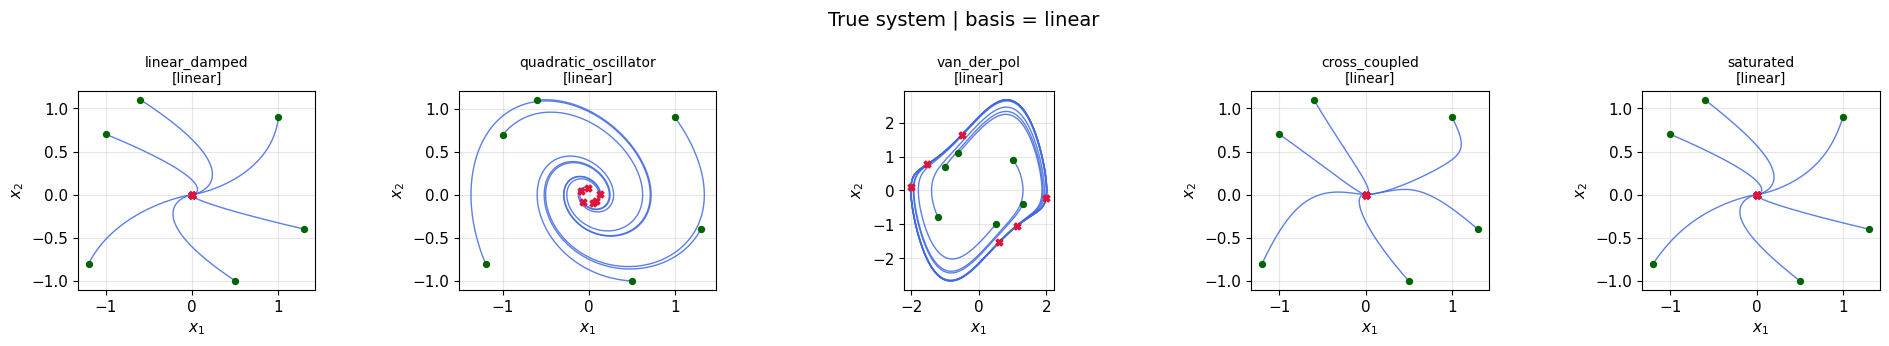

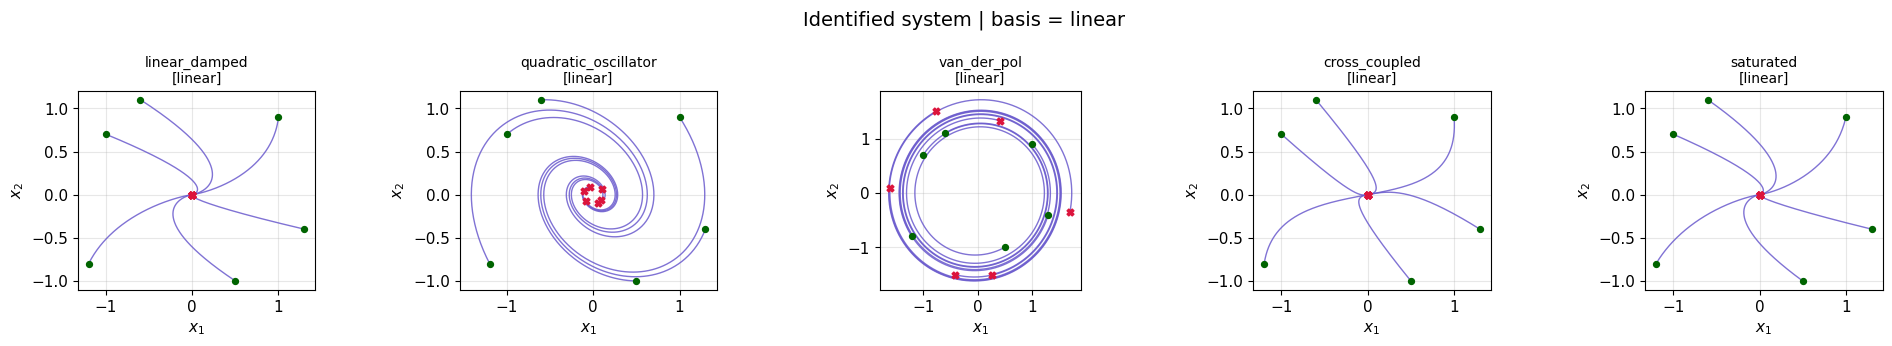

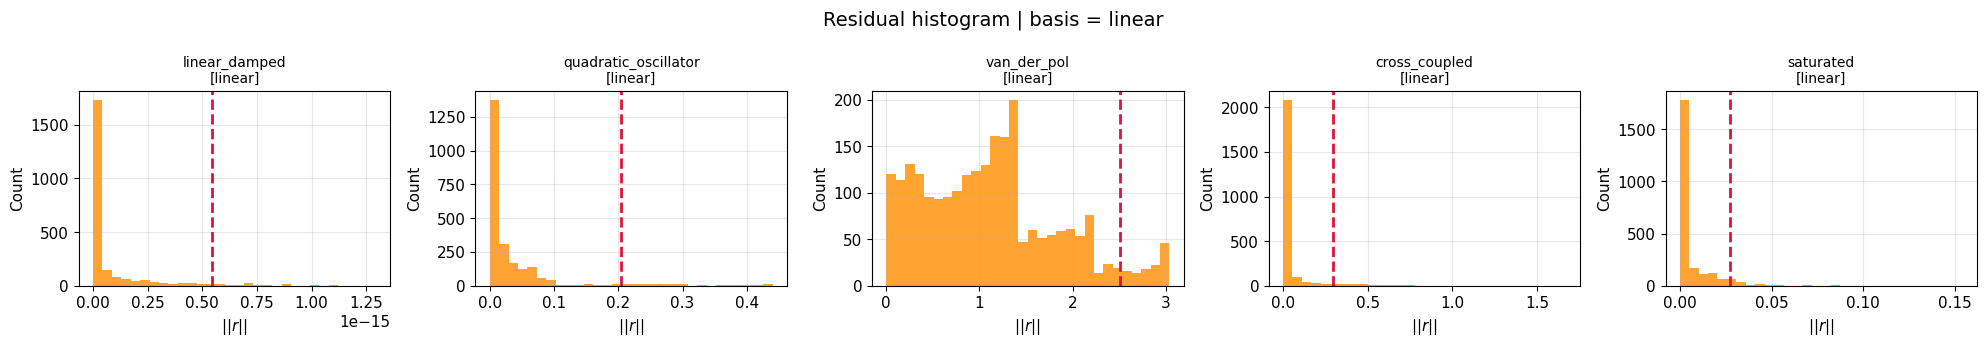

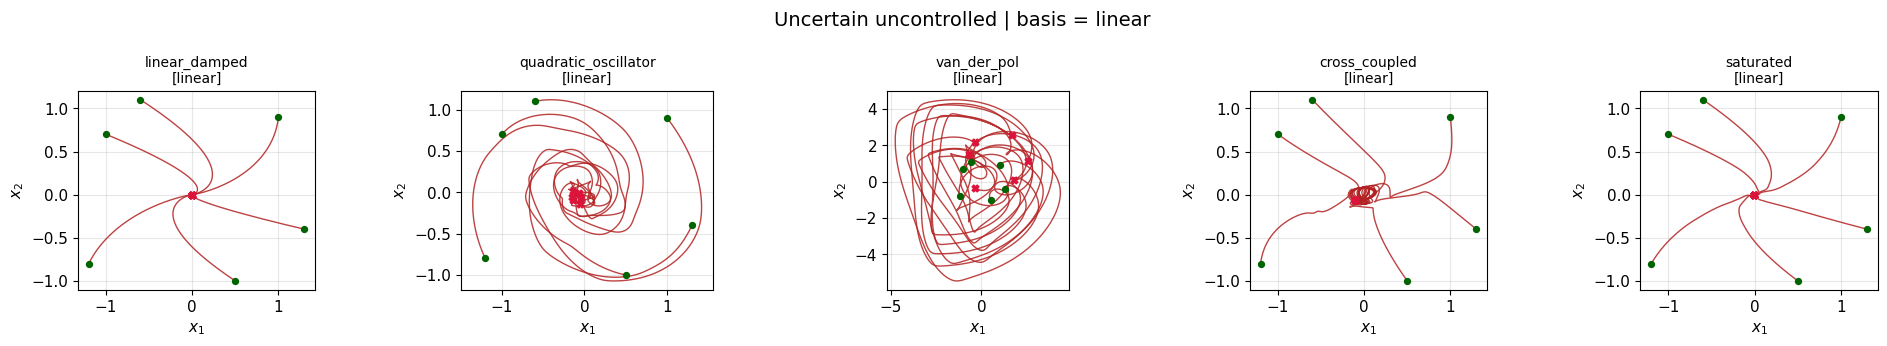

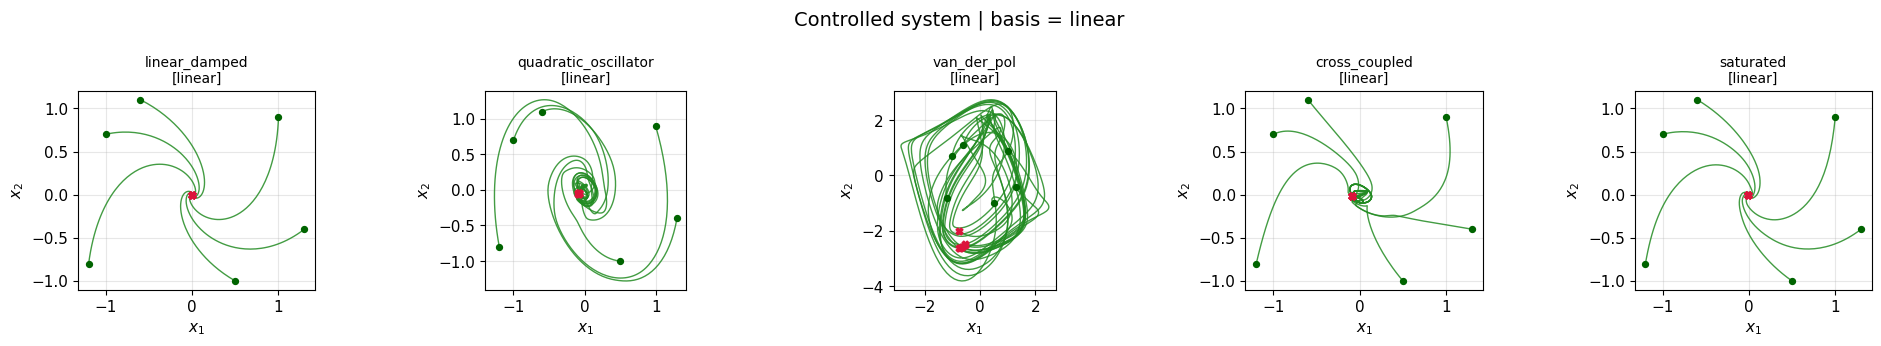


Словарь: quadratic


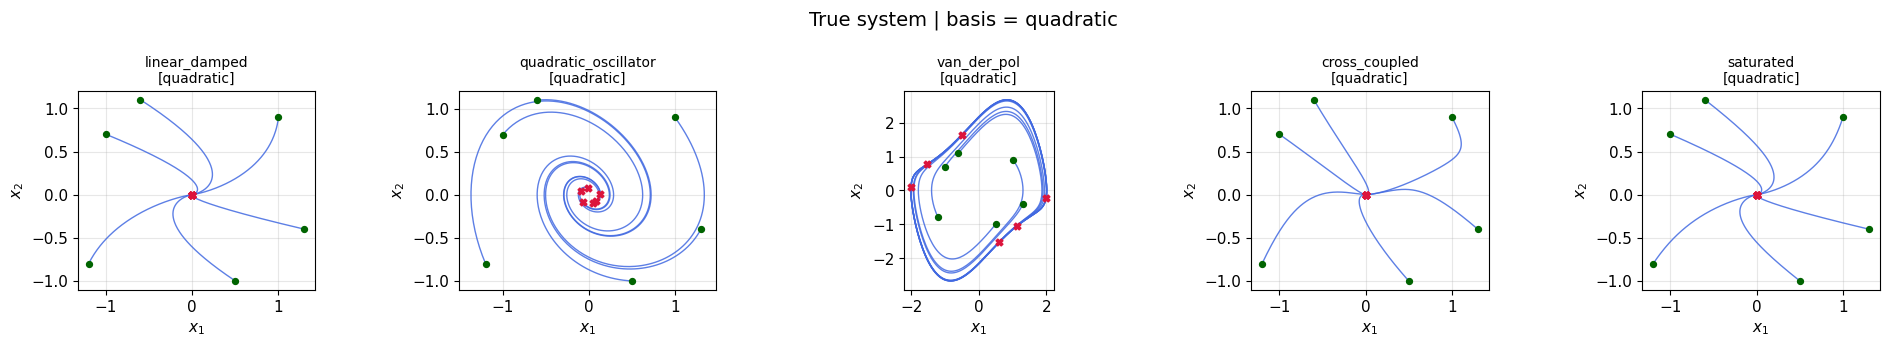

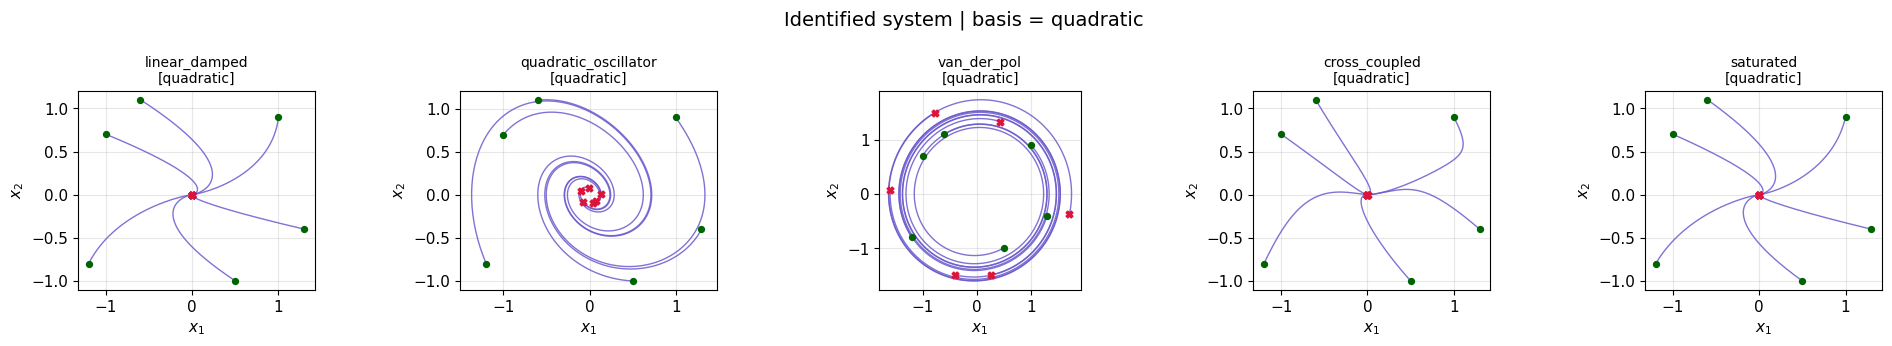

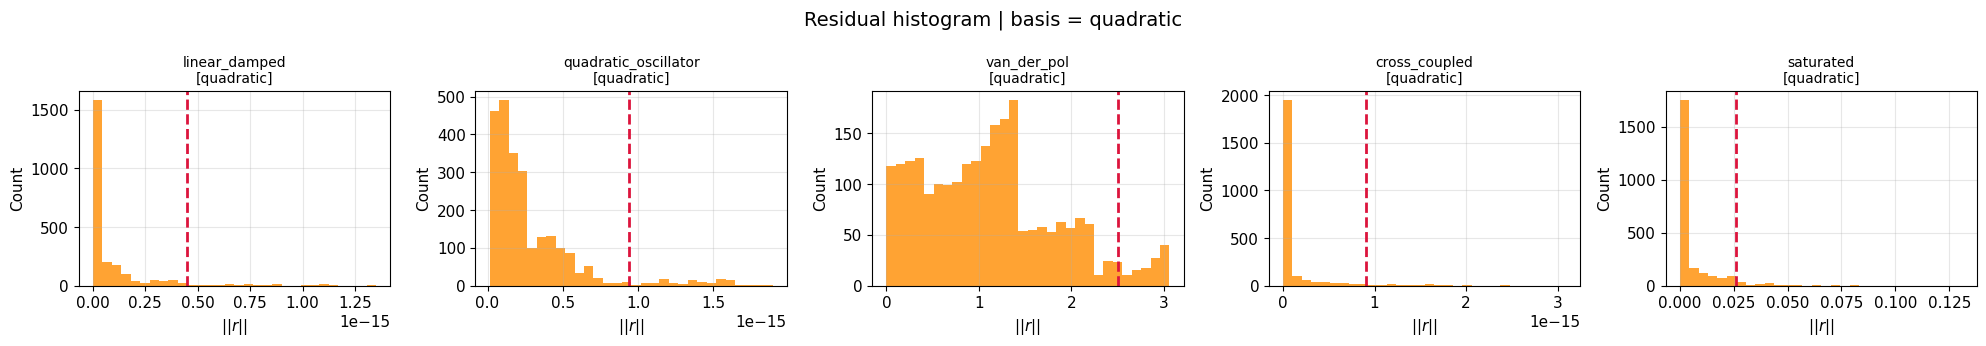

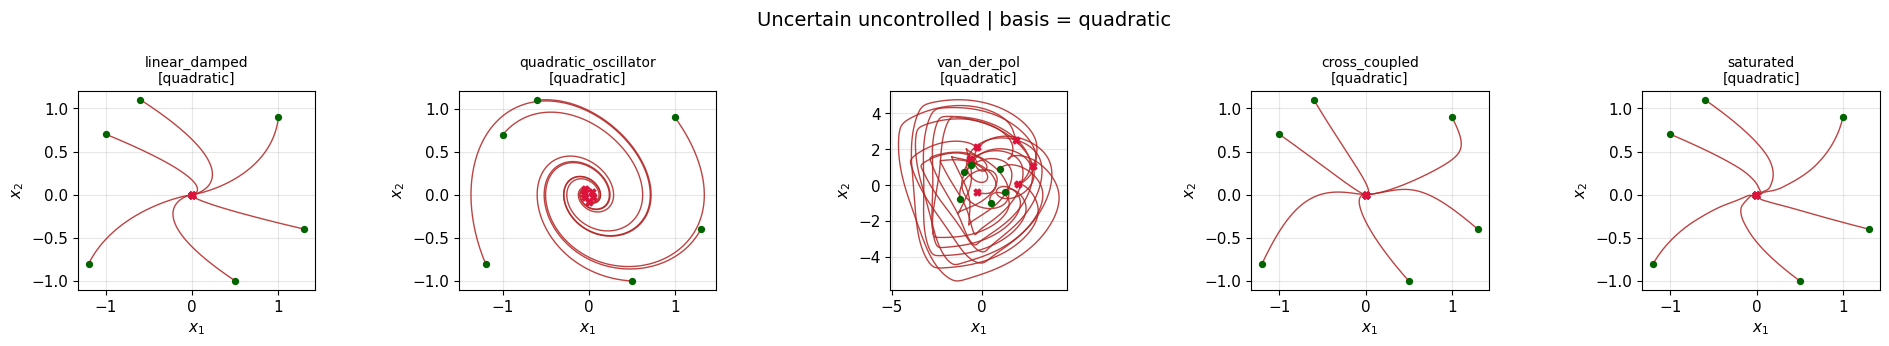

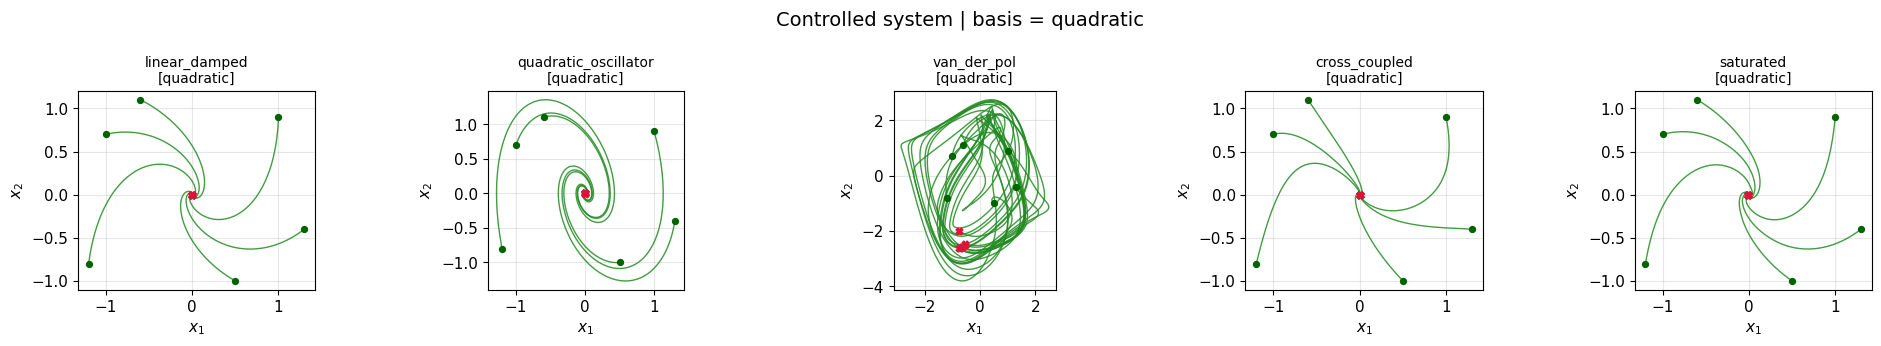


Словарь: quadratic_with_constant


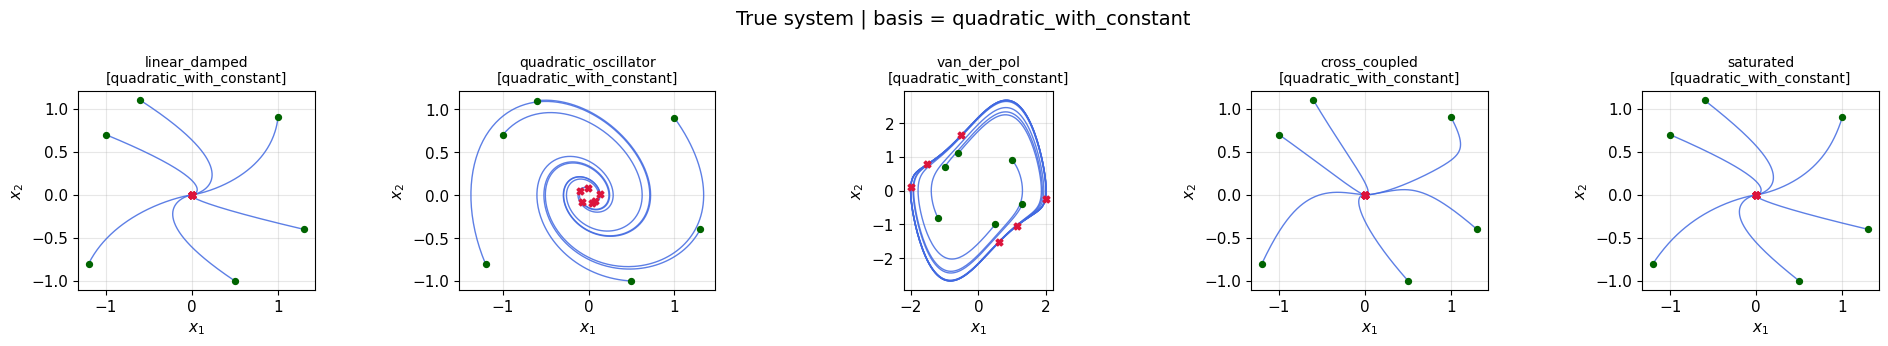

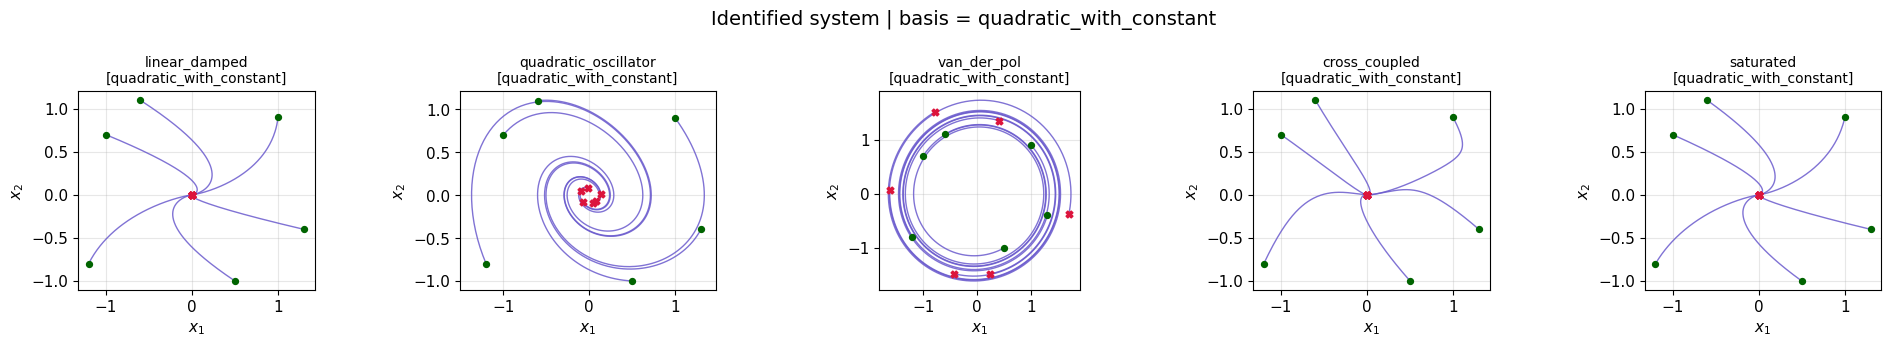

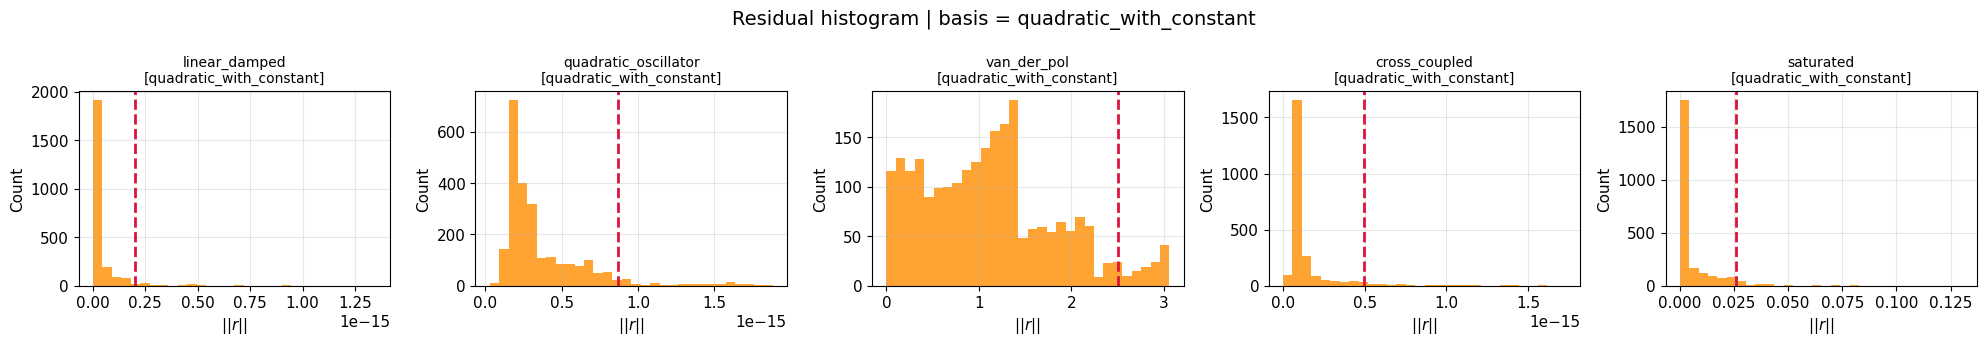

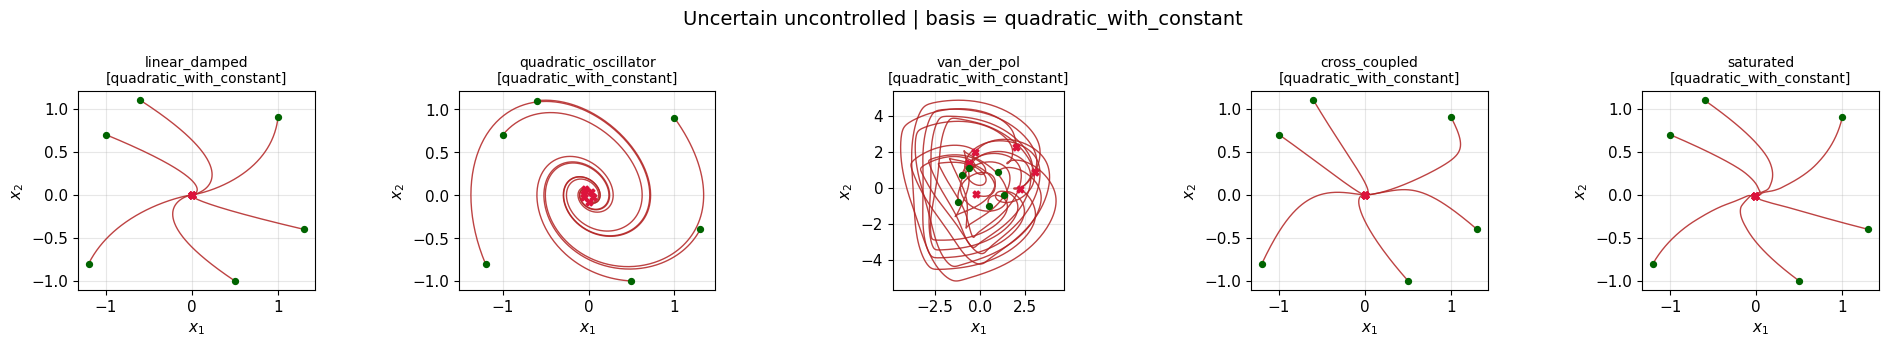

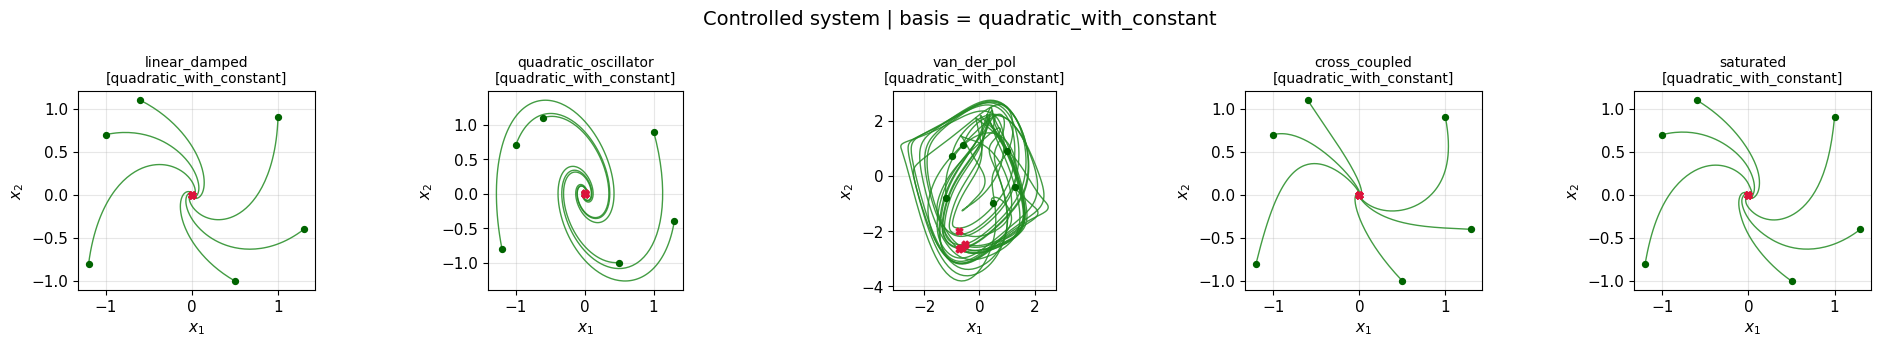

In [28]:
row_specs = [
    ('traj_true', 'True system', 'royalblue', 'phase'),
    ('traj_hat', 'Identified system', 'slateblue', 'phase'),
    ('residual_norms', 'Residual histogram', 'darkorange', 'residual'),
    ('traj_unc', 'Uncertain uncontrolled', 'firebrick', 'phase'),
    ('traj_cl', 'Controlled system', 'forestgreen', 'phase'),
]

for basis_name in basis_configs:
    print(f'\nСловарь: {basis_name}')
    for key, label, color, plot_type in row_specs:
        fig, axes = plt.subplots(1, len(examples), figsize=(4 * len(examples), 3.5), squeeze=False)
        axes = axes.ravel()

        for ax, example_name in zip(axes, examples):
            entry = results_dict[example_name][basis_name]
            if plot_type == 'phase':
                trajectories = entry[key]
                for _, states in trajectories:
                    ax.plot(states[:, 0], states[:, 1], color=color, lw=1.0, alpha=0.85)
                    ax.scatter(states[0, 0], states[0, 1], color='darkgreen', s=18, marker='o', zorder=3)
                    ax.scatter(states[-1, 0], states[-1, 1], color='crimson', s=24, marker='X', zorder=3)
                ax.set_xlabel('$x_1$')
                ax.set_ylabel('$x_2$')
                ax.set_aspect('equal', adjustable='box')
            else:
                ax.hist(entry['residual_norms'], bins=30, alpha=0.8, color=color)
                ax.axvline(entry['metrics']['epsilon'], color='crimson', linestyle='--', linewidth=2)
                ax.set_xlabel('$||r||$')
                ax.set_ylabel('Count')

            ax.set_title(f'{example_name}\n[{basis_name}]', fontsize=10)
            ax.grid(True, alpha=0.3)

        fig.suptitle(f'{label} | basis = {basis_name}', fontsize=14)
        plt.tight_layout()
        save_figure(FIGURES_DIR / f'row_{basis_name}_{key}.png')
        plt.show()
        plt.close(fig)


## Сводная таблица по всем системам и словарям


In [29]:
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

save_dataframe(summary_df, TABLES_DIR / 'all_examples_all_bases_summary.csv')
save_json(summary_rows, METRICS_DIR / 'all_examples_all_bases_summary.json')
print(f'Сводка сохранена в: {TABLES_DIR / "all_examples_all_bases_summary.csv"}')


,example,basis,theta,epsilon,mean_residual_norm,max_residual_norm,q95_residual_norm,is_hurwitz
0,linear_damped,linear,x1 + x2,5.467214e-16,8.692308e-17,1.294731e-15,5.467214e-16,True
1,linear_damped,quadratic,x1 + x2 + x1^2 + x2^2 + x1*x2,4.475452e-16,9.536143e-17,1.350645e-15,4.475452e-16,True
2,linear_damped,quadratic_with_constant,1 + x1 + x2 + x1^2 + x2^2 + x1*x2,2.001483e-16,5.016795e-17,1.350645e-15,2.001483e-16,True
3,quadratic_oscillator,linear,x1 + x2,2.049280e-01,3.734432e-02,4.401307e-01,2.049280e-01,True
4,quadratic_oscillator,quadratic,x1 + x2 + x1^2 + x2^2 + x1*x2,9.442576e-16,2.860731e-16,1.897150e-15,9.442576e-16,True
5,quadratic_oscillator,quadratic_with_constant,1 + x1 + x2 + x1^2 + x2^2 + x1*x2,8.671119e-16,3.710227e-16,1.884111e-15,8.671119e-16,True
6,van_der_pol,linear,x1 + x2,2.510692e+00,1.115211e+00,3.038276e+00,2.510692e+00,False
7,van_der_pol,quadratic,x1 + x2 + x1^2 + x2^2 + x1*x2,2.506479e+00,1.114950e+00,3.058323e+00,2.506479e+00,False
8,van_der_pol,quadratic_with_constant,1 + x1 + x2 + x1^2 + x2^2 + x1*x2,2.507332e+00,1.114945e+00,3.062631e+00,2.507332e+00,False
9,cross_coupled,linear,x1 + x2,2.962958e-01,4.548077e-02,1.672916e+00,2.962958e-01,True


Сводка сохранена в: /Users/maksimkuznecov/Desktop/graduate_work/robust-dd-control/results/main_pipeline/tables/all_examples_all_bases_summary.csv


## Сравнение словарей по среднему residual norm


basis,linear,quadratic,quadratic_with_constant
example,,,
cross_coupled,4.548077e-02,1.386334e-16,1.609089e-16
linear_damped,8.692308e-17,9.536143e-17,5.016795e-17
quadratic_oscillator,3.734432e-02,2.860731e-16,3.710227e-16
saturated,5.658273e-03,5.526321e-03,5.839081e-03
van_der_pol,1.115211e+00,1.114950e+00,1.114945e+00


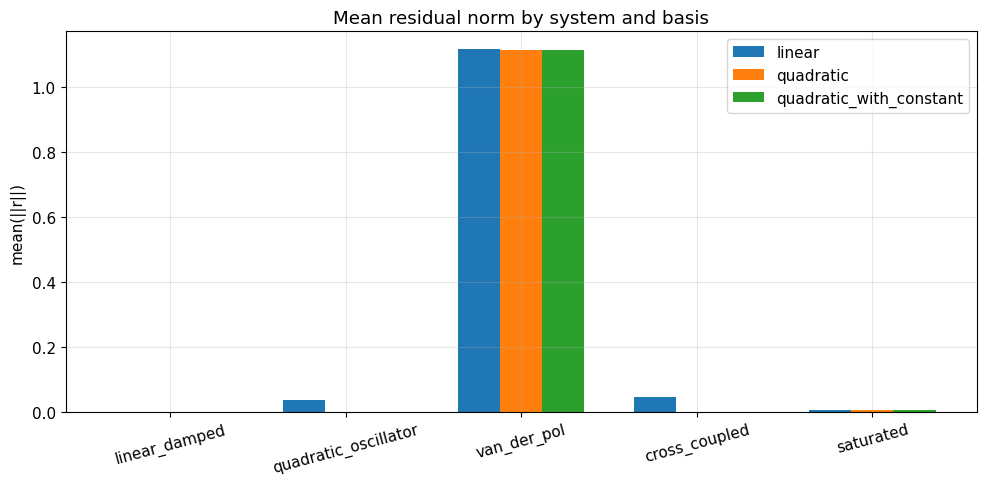

In [30]:
pivot_mean = summary_df.pivot(index='example', columns='basis', values='mean_residual_norm')
display(pivot_mean)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(examples))
width = 0.24

for idx, basis_name in enumerate(basis_configs):
    values = [pivot_mean.loc[example_name, basis_name] for example_name in examples]
    ax.bar(x + (idx - 1) * width, values, width=width, label=basis_name)

ax.set_xticks(x)
ax.set_xticklabels(examples, rotation=15)
ax.set_ylabel('mean(||r||)')
ax.set_title('Mean residual norm by system and basis')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_figure(FIGURES_DIR / 'summary_mean_residual_by_basis.png')
plt.show()
plt.close()


## Детальные метрики по каждой системе


In [31]:
for example_name in examples:
    print(f"\n{'=' * 70}")
    print(f'Система: {example_name}')
    print(f"{'=' * 70}")
    for basis_name in basis_configs:
        m = results_dict[example_name][basis_name]['metrics']
        print(f'  basis = {basis_name}')
        print(f"    Θ(x): {', '.join(m['theta_terms'])}")
        print(f"    K ({m['K_name']}): {m['K']}")
        print(f"    epsilon: {m['epsilon']:.8f}")
        print(f"    mean(||r||): {m['residual_mean']:.8f}")
        print(f"    max(||r||): {m['residual_max']:.8f}")
        print(f"    q95(||r||): {m['residual_q95']:.8f}")
        print(f"    Hurwitz: {m['is_hurwitz']}")



Система: linear_damped
  basis = linear
    Θ(x): x1, x2
    K (medium): [[-1.5, -0.6]]
    epsilon: 0.00000000
    mean(||r||): 0.00000000
    max(||r||): 0.00000000
    q95(||r||): 0.00000000
    Hurwitz: True
  basis = quadratic
    Θ(x): x1, x2, x1^2, x2^2, x1*x2
    K (medium): [[-1.5, -0.6]]
    epsilon: 0.00000000
    mean(||r||): 0.00000000
    max(||r||): 0.00000000
    q95(||r||): 0.00000000
    Hurwitz: True
  basis = quadratic_with_constant
    Θ(x): 1, x1, x2, x1^2, x2^2, x1*x2
    K (medium): [[-1.5, -0.6]]
    epsilon: 0.00000000
    mean(||r||): 0.00000000
    max(||r||): 0.00000000
    q95(||r||): 0.00000000
    Hurwitz: True

Система: quadratic_oscillator
  basis = linear
    Θ(x): x1, x2
    K (medium): [[-1.5, -0.6]]
    epsilon: 0.20492804
    mean(||r||): 0.03734432
    max(||r||): 0.44013071
    q95(||r||): 0.20492804
    Hurwitz: True
  basis = quadratic
    Θ(x): x1, x2, x1^2, x2^2, x1*x2
    K (medium): [[-1.5, -0.6]]
    epsilon: 0.00000000
    mean(||r||): 

## Итог


In [32]:
print('\n' + '=' * 70)
print('ИТОГОВЫЙ ОТЧЁТ')
print('=' * 70)
print(f'Систем: {len(examples)}')
print(f'Словарей на систему: {len(basis_configs)}')
print(f'Всего прогонов: {len(examples) * len(basis_configs)}')
print(f'Используемая матрица K ({K_name}): {K.tolist()}')
print(f'Папка результатов: {NOTEBOOK_RESULTS}')
print('Сохранены:')
print(f'  datasets  -> {DATASETS_DIR}')
print(f'  figures   -> {FIGURES_DIR}')
print(f'  tables    -> {TABLES_DIR}')
print(f'  metrics   -> {METRICS_DIR}')
print('=' * 70)



ИТОГОВЫЙ ОТЧЁТ
Систем: 5
Словарей на систему: 3
Всего прогонов: 15
Используемая матрица K (medium): [[-1.5, -0.6]]
Папка результатов: /Users/maksimkuznecov/Desktop/graduate_work/robust-dd-control/results/main_pipeline
Сохранены:
  datasets  -> /Users/maksimkuznecov/Desktop/graduate_work/robust-dd-control/results/main_pipeline/datasets
  figures   -> /Users/maksimkuznecov/Desktop/graduate_work/robust-dd-control/results/main_pipeline/figures
  tables    -> /Users/maksimkuznecov/Desktop/graduate_work/robust-dd-control/results/main_pipeline/tables
  metrics   -> /Users/maksimkuznecov/Desktop/graduate_work/robust-dd-control/results/main_pipeline/metrics
